In [1]:
from torch import nn
import torch
from torchmetrics import Accuracy, Precision, Recall, F1Score, ConfusionMatrix
from torchvision import datasets, transforms
from torch.nn import functional as F
from torch.optim import Adam, SGD
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from torch.utils.data import DataLoader
import seaborn as sns
from PIL import Image

/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Defining device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_data = datasets.MNIST('data',
                            train=True,
                            download=True,
                            transform=transforms.ToTensor())

test_data = datasets.MNIST('data',
                            train=False,
                            download=True,
                            transform=transforms.ToTensor())
BATCH_SIZE = 32
class_names = train_data.classes
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=True)

print(f'Length of train data: {len(train_data)}')
print(f'Length of test data: {len(test_data)}')

Length of train data: 60000
Length of test data: 10000


In [3]:
torch.cuda.is_available()
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [19]:
train_data[0][0].shape, train_data.classes

(torch.Size([1, 28, 28]),
 ['0 - zero',
  '1 - one',
  '2 - two',
  '3 - three',
  '4 - four',
  '5 - five',
  '6 - six',
  '7 - seven',
  '8 - eight',
  '9 - nine'])

In [20]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

# Model
class ModelWithoutConv2d(nn.Module):
    def __init__(self, input_size, hidden_units_1, hidden_units_2):
        super().__init__()
        self.seq_layer = nn.Sequential(nn.Flatten(),
            nn.Linear(in_features=input_size, out_features=hidden_units_1),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units_1, out_features=hidden_units_2),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units_2, out_features=10),
            )

    def forward(self, x):
        return self.seq_layer(x)

class ModelWithConv2d(nn.Module):
    def __init__(self, input_size: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_size,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)
        return x

basic_model = ModelWithoutConv2d(input_size=784, hidden_units_1=128, hidden_units_2=64).to(device)
advanced_model = ModelWithConv2d(input_size=1, hidden_units=10, output_shape=len(class_names)).to(device)
criterion = nn.CrossEntropyLoss().to(device)
optimizer_0 = Adam(params=basic_model.parameters(), lr=0.01)
optimizer_1 = SGD(params=advanced_model.parameters(), lr=0.1)
basic_model_name = 'Модель з прикладу в методичці'
advanced_model_name = 'Модель TinyVGG'

In [21]:
def training_step(model: torch.nn.Module,
                  data_loader: torch.utils.data.DataLoader,
                  loss_fn: torch.nn.Module,
                  optimizer:torch.optim.Optimizer) -> (float, torch.Tensor, torch.Tensor):
    loss_count: int = 0

    model.train()
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)
        train_pred = model(X)
        loss = loss_fn(train_pred, y)
        loss_count += loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    loss_count /= len(data_loader)
    # print(f'Train loss: {loss_count:.3f}')
    return loss_count

def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    all_preds = []
    all_labels = []
    test_loss = 0
    model.to(device)
    model.eval()

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            test_pred = model(X)
            test_loss += loss_fn(test_pred, y)
            preds = torch.argmax(test_pred, dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())

        all_preds = torch.cat(all_preds)
        all_labels = torch.cat(all_labels)
        test_loss /= len(data_loader)

        return test_loss, all_preds, all_labels

In [22]:
train_time_start_on_gpu = timer()

epochs_train_lt_basic = []
epochs_test_lt_basic = []

epochs = 5
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    epochs_train_lt_basic.append(training_step(data_loader=train_dataloader,
                                         model=basic_model,
                                         loss_fn=criterion,
                                         optimizer=optimizer_0).cpu().item())
    test_loss_var, y_preds_basic, y_true_basic = test_step(data_loader=test_dataloader,
                                                 model=basic_model,
                                                 loss_fn=criterion)
    epochs_test_lt_basic.append(test_loss_var.cpu().item())

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
---------


 20%|██        | 1/5 [00:06<00:24,  6.22s/it]

Epoch: 1
---------


 40%|████      | 2/5 [00:12<00:18,  6.18s/it]

...

Epoch: 3
---------


 80%|████████  | 4/5 [00:25<00:06,  6.28s/it]

Epoch: 4
---------


100%|██████████| 5/5 [00:31<00:00,  6.26s/it]

Train time on cuda: 31.327 seconds


In [23]:
train_time_start_on_gpu = timer()

epochs_train_lt_advanced = []
epochs_test_lt_advanced = []

epochs = 5
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    epochs_train_lt_advanced.append(training_step(data_loader=train_dataloader,
                                         model=advanced_model,
                                         loss_fn=criterion,
                                         optimizer=optimizer_1).cpu().item())
    test_loss_var, y_preds_advanced, y_true_advanced = test_step(data_loader=test_dataloader,
                                                 model=advanced_model,
                                                 loss_fn=criterion)
    epochs_test_lt_advanced.append(test_loss_var.cpu().item())

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
---------


 20%|██        | 1/5 [00:07<00:28,  7.05s/it]

Epoch: 1
---------


 40%|████      | 2/5 [00:14<00:21,  7.10s/it]

...

Epoch: 3
---------


 80%|████████  | 4/5 [00:27<00:06,  6.95s/it]

Epoch: 4
---------


100%|██████████| 5/5 [00:35<00:00,  7.02s/it]

Train time on cuda: 35.112 seconds


In [54]:
def calc_metrics(y_preds, y_true, epochs_train_lt, epochs_test_lt, epochs_num, model_name):
    acc_fn = Accuracy(task="multiclass", num_classes=10)
    accuracy = acc_fn(y_preds, y_true)
    print(f"Загальна точність (Accuracy): {accuracy.item():.4f}")

    conf_matrix_fn = ConfusionMatrix(task="multiclass", num_classes=10)
    prec_fn_macro = Precision(task="multiclass", num_classes=10, average='macro')
    recall_fn_macro = Recall(task="multiclass", num_classes=10, average='macro')
    f1_fn_macro = F1Score(task="multiclass", num_classes=10, average='macro')

    conf_matrix = conf_matrix_fn(y_preds, y_true).numpy()
    precision_macro = prec_fn_macro(y_preds, y_true)
    recall_macro = recall_fn_macro(y_preds, y_true)
    f1_macro = f1_fn_macro(y_preds, y_true)

    print(f"Усереднена прецизійність (Macro Precision): {precision_macro.item():.4f}")
    print(f"Усереднена повнота (Macro Recall): {recall_macro.item():.4f}")
    print(f"Усереднений F1-Score (Macro F1-Score): {f1_macro.item():.4f}")
    fig, ax = plt.subplots(nrows=2, figsize=(12, 10))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax = ax[0]
    )
    ax[0].set_xlabel('Передбачений клас (Predicted Label)')
    ax[0].set_ylabel('Справжній клас (True Label)')
    ax[0].set_title('Матриця помилок (Confusion Matrix)')

    ax[1].plot(range(epochs_num), epochs_train_lt, label="Train loss")
    ax[1].plot(range(epochs_num), epochs_test_lt, label="Test loss")
    ax[1].set_title(f"Модель: {model_name}")
    ax[1].set_ylabel("Loss")
    ax[1].set_xlabel("Epochs")
    ax[1].legend()
    plt.show()

Загальна точність (Accuracy): 0.9577
Усереднена прецизійність (Macro Precision): 0.9571
Усереднена повнота (Macro Recall): 0.9574
Усереднений F1-Score (Macro F1-Score): 0.9570


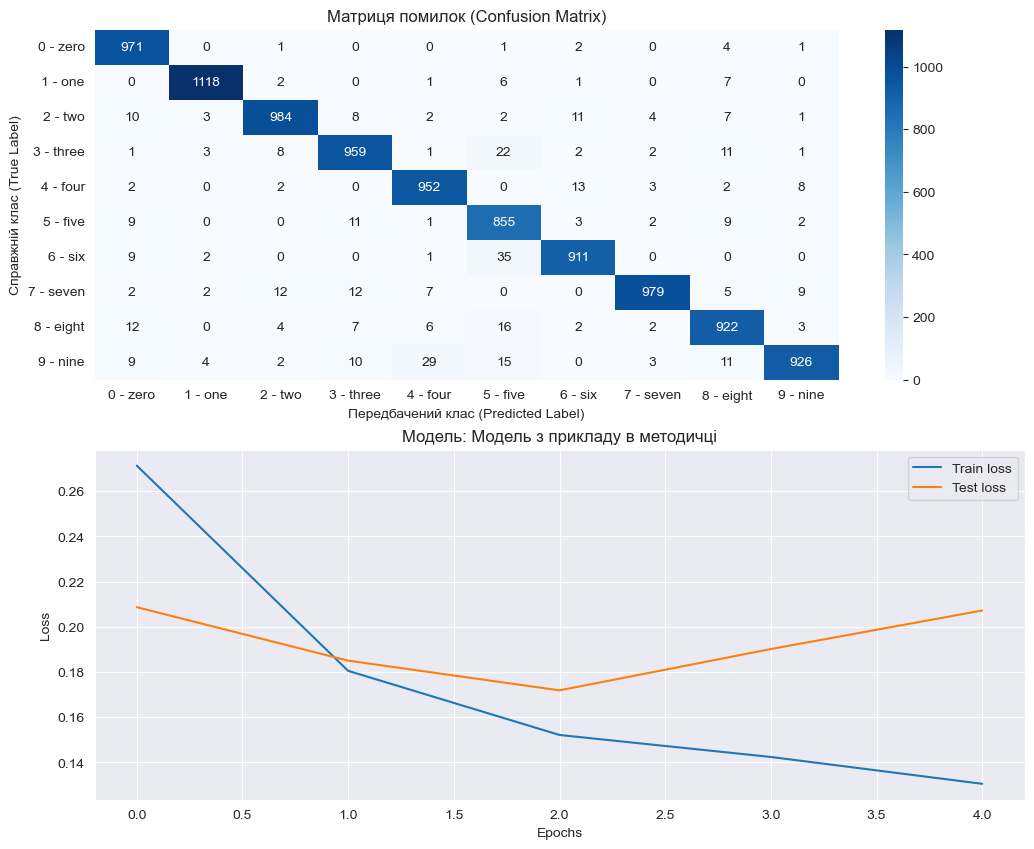

In [55]:
calc_metrics(y_preds_basic, y_true_basic, epochs_train_lt_basic, epochs_test_lt_basic, epochs, basic_model_name)

Загальна точність (Accuracy): 0.9843
Усереднена прецизійність (Macro Precision): 0.9842
Усереднена повнота (Macro Recall): 0.9843
Усереднений F1-Score (Macro F1-Score): 0.9842


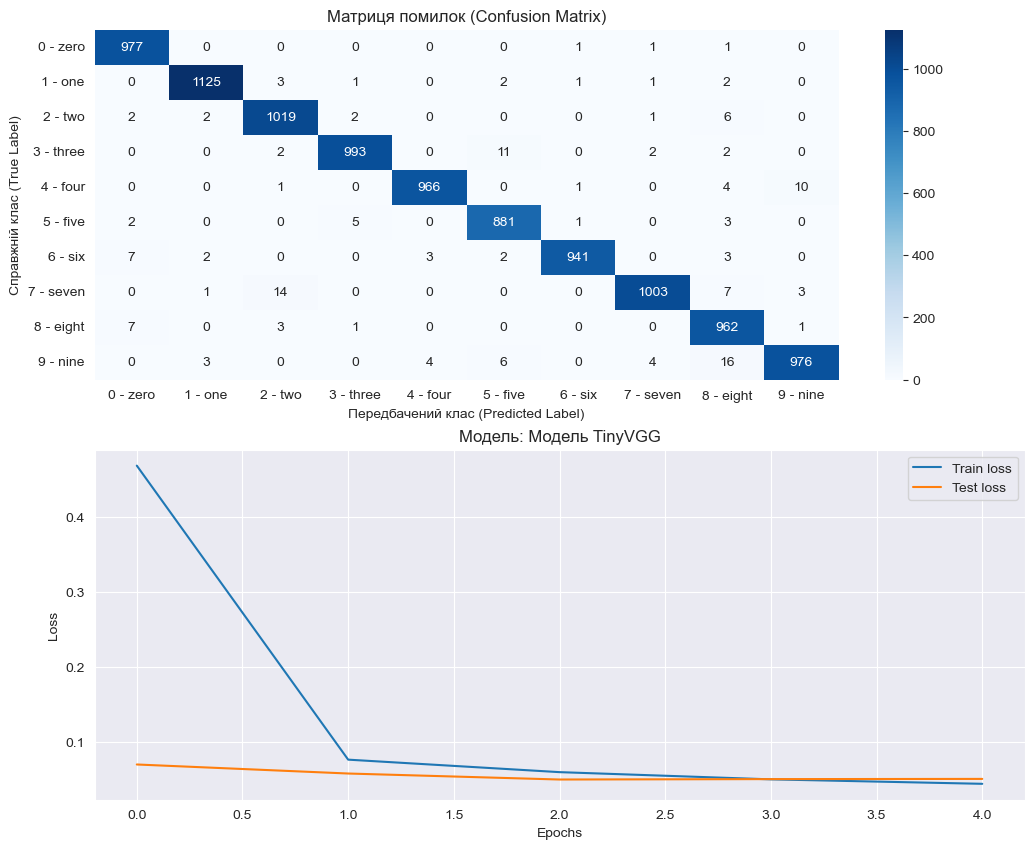

In [56]:
calc_metrics(y_preds_advanced, y_true_advanced, epochs_train_lt_advanced, epochs_test_lt_advanced, epochs, advanced_model_name)

In [26]:
def check_model(model, image, label):
    model.eval()

    with torch.inference_mode():
        logits = model(image.to(device))
        # probabilities = torch.softmax(logits, dim=1)
        # predicted_class = torch.argmax(probabilities, dim=1)
        predicted_class = torch.argmax(logits, dim=1)

    print(f"Logits: {logits}")
    # print(f"Probabilities: {probabilities}")
    print(f"Predicted class: {predicted_class.cpu().item()}")
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(label)
    plt.show()

Перевірка точності роботи моделі на тестових даних
Logits: tensor([[ 3.7559e+01, -5.7352e+01, -1.4774e+01, -2.9291e+01, -4.9313e+01,
         -4.5653e+00, -4.4131e-02, -1.9916e+01, -1.2261e+01, -1.6697e+01]],
       device='cuda:0')
Predicted class: 0


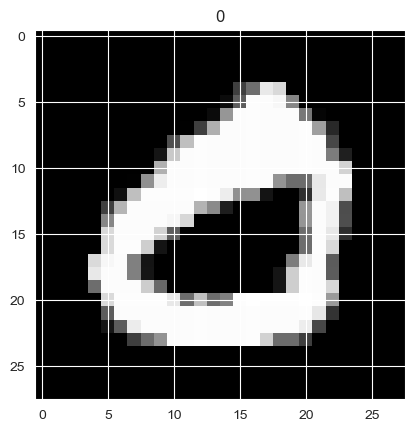

In [57]:
X, y = train_data[np.random.randint(len(train_data))]
print('Перевірка точності роботи моделі на тестових даних')
check_model(basic_model, X, y)

In [58]:
# Conveyor for image
preprocess_transform = transforms.Compose([transforms.Grayscale(num_output_channels=1), transforms.Resize((28, 28), antialias=True),
                                           transforms.Lambda(lambda image: transforms.functional.invert(image)),
                                           transforms.ToTensor()])

def prepare_image(image_path):
    try:
        img = Image.open(image_path)
    except FileNotFoundError:
        print(f"Помилка: Файл не знайдено за шляхом {image_path}")
        return None

    tensor = preprocess_transform(img)

    tensor = tensor.unsqueeze(0)

    return tensor

Перевірка точності роботи моделі на власноруч створених даних
Logits: tensor([[-0.8153,  2.2308,  2.6602,  1.3014, -3.2420,  1.5868, -1.4157, -2.2401,
          0.5278, -0.7707]], device='cuda:0')
Predicted class: 2


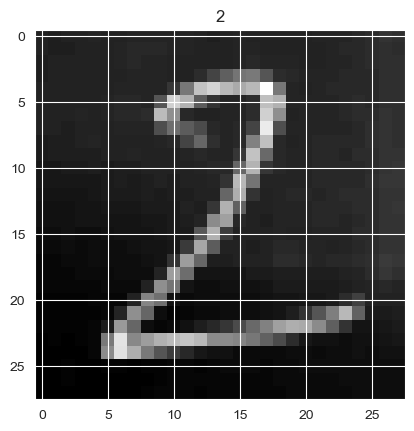

In [106]:
image_path_lt = [['data/hand_made/number_0.png', 0],
                 ['data/hand_made/number_1.png', 1],
                 ['data/hand_made/number_2.png', 2],
                 ['data/hand_made/photo_2025-10-16_12-44-54.jpg', 1],
                 ['data/hand_made/photo_2025-10-16_12-44-55.jpg', 2],
                 ['data/hand_made/photo_2025-10-16_12-44-55 (2).jpg', 3],
                 ['data/hand_made/photo_2025-10-16_12-44-55 (3).jpg', 7],
                 ['data/hand_made/photo_2025-10-16_12-44-55 (4).jpg', 0],
                 ['data/hand_made/photo_2025-10-16_12-44-56.jpg', 2]]
# image_path = 'data/hand_made/photo_2025-10-16_12-44-55 (4).jpg'
final_tensor, new_num_label = image_path_lt[np.random.randint(len(image_path_lt))]
final_tensor = prepare_image(final_tensor)

Перевірка точності роботи моделі на власноруч створених даних
Logits: tensor([[-2.2042,  2.2259,  0.8027,  0.9346, -1.0325,  1.5144, -2.2619, -1.3714,
          0.7356,  0.4377]], device='cuda:0')
Predicted class: 1


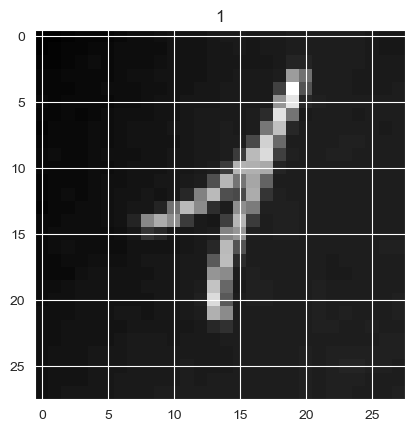

In [101]:
print('Перевірка точності роботи моделі на власноруч створених даних')
check_model(advanced_model, final_tensor, new_num_label)